# Finlora Finance Flow — Fraud Detection & Risk Scoring
## Model Development

This notebook develops two fraud-classification models:
1. Logistic Regression — interpretable baseline.
2. Random Forest — non-linear prototype.

The pipeline uses a stratified 75/25 train-test split and SMOTE on the training data only.

In [1]:
#  IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
import joblib
import os

print("Libraries imported successfully.")

Libraries imported successfully.


##  Load the Feature-Engineered Dataset

The dataset already contains the original variables and engineered features such as log transformations, cyclical time features, behavioural flags and account/device features.

In [2]:
#  LOAD DATASET

file_path = r"C:\Users\telvi\Downloads\AMDARI\finlora_finance_flow\data\processed_data\finlora_features.csv"

df = pd.read_csv(file_path)

In [3]:
print("Dataset shape:", df.shape)

print("\nFraud distribution:")
print(df["is_fraud"].value_counts())

print("\nFraud percentage:")
print(df["is_fraud"].value_counts(normalize=True).mul(100).round(2))

Dataset shape: (126000, 41)

Fraud distribution:
is_fraud
0    122648
1      3352
Name: count, dtype: int64

Fraud percentage:
is_fraud
0    97.34
1     2.66
Name: proportion, dtype: float64


##  Inspect Engineered Features

In [4]:
#  ENGINEERED FEATURES

engineered_features = [
    "log_amount", "log_amount_to_avg_ratio",
    "hour_sin", "hour_cos", "day_sin", "day_cos",
    "high_amount_ratio_flag", "high_velocity_flag",
    "new_device_flag", "cross_border_flag",
    "account_age_group", "device_status_unknown"
]

print("Engineered features:")
for feature in engineered_features:
    print(f"- {feature}")

display(df[engineered_features].head(10))

Engineered features:
- log_amount
- log_amount_to_avg_ratio
- hour_sin
- hour_cos
- day_sin
- day_cos
- high_amount_ratio_flag
- high_velocity_flag
- new_device_flag
- cross_border_flag
- account_age_group
- device_status_unknown


,log_amount,log_amount_to_avg_ratio,hour_sin,hour_cos,day_sin,day_cos,high_amount_ratio_flag,high_velocity_flag,new_device_flag,cross_border_flag,account_age_group,device_status_unknown
0,11.341354,2.323368,-5.000000e-01,-0.866025,-0.781831,0.623490,1,0,0,0,mature,1
1,9.120889,0.693147,-2.588190e-01,-0.965926,0.974928,-0.222521,0,0,0,0,mature,1
2,9.934986,1.181727,1.224647e-16,-1.000000,0.433884,-0.900969,0,0,0,0,mature,0
3,8.064143,0.190620,-5.000000e-01,-0.866025,0.000000,1.000000,0,0,0,0,mature,1
4,11.491094,1.088562,-8.660254e-01,-0.500000,-0.974928,-0.222521,0,0,0,0,mature,0
5,10.811960,0.693147,1.224647e-16,-1.000000,0.781831,0.623490,0,0,0,1,mature,0
6,12.239581,1.642873,-9.659258e-01,-0.258819,0.974928,-0.222521,1,0,0,0,mature,0
7,8.701494,0.029559,-9.659258e-01,0.258819,-0.781831,0.623490,0,0,0,0,mature,0
8,10.356451,0.693147,-8.660254e-01,0.500000,0.781831,0.623490,0,0,0,0,mature,0
9,8.783614,0.190620,-5.000000e-01,0.866025,-0.974928,-0.222521,0,0,0,0,mature,0


# MODEL DEVELOPMENT

## Define Predictors and Target

Identifiers, raw text, dates and the potentially post-outcome `status` field are excluded. The target `is_fraud` is kept separately.

In [5]:
#  DEFINE FEATURES (X) AND TARGET (y)

drop_features = [
    "transaction_id",
    "account_id",
    "description",
    "merchant_name",
    "device_id",
    "account_holder_name",
    "timestamp",
    "account_created_date",
    "status",
    "is_fraud"
]

X = df.drop(columns=drop_features)
y = df["is_fraud"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (126000, 31)
Target shape: (126000,)

Target distribution:
is_fraud
0    122648
1      3352
Name: count, dtype: int64


## Identify Categorical and Numerical Features

This step prevents the earlier `ValueError: could not convert string to float: 'Wednesday'`.

Text/object columns such as `day_of_week` are treated as categorical and will be one-hot encoded.

In [6]:
#  IDENTIFY CATEGORICAL AND NUMERICAL FEATURES

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numeric_features)

Categorical features:
['account_type', 'kyc_tier', 'day_of_week', 'merchant_category', 'channel', 'currency', 'transaction_country', 'home_country', 'account_age_group']

Numerical features:
['hour_of_day', 'amount', 'amount_to_avg_ratio', 'avg_transaction_amount_30d', 'transaction_velocity_1h', 'is_cross_border', 'is_new_device', 'account_age_days', 'negative_avg_flag', 'personal_spend_baseline_usd', 'log_amount', 'log_amount_to_avg_ratio', 'hour_sin', 'hour_cos', 'day_of_week_num', 'day_sin', 'day_cos', 'high_amount_ratio_flag', 'high_velocity_flag', 'new_device_flag', 'cross_border_flag', 'device_status_unknown']


## Stratified 75/25 Train-Test Split

Stratification preserves the fraud/legitimate class proportions in both sets.

In [7]:
# STRATIFIED TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTest target distribution:")
print(y_test.value_counts())

Training set: (94500, 31)
Test set: (31500, 31)

Training target distribution:
is_fraud
0    91986
1     2514
Name: count, dtype: int64

Test target distribution:
is_fraud
0    30662
1      838
Name: count, dtype: int64


##  One-Hot Encode Categorical Features

The encoder learns from the training data only. `handle_unknown="ignore"` prevents errors if a category appears in the test set but was not present in training.

In [8]:
#  ONE-HOT ENCODING

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features
        )
    ],
    remainder="passthrough"
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)

Encoded training shape: (94500, 73)
Encoded test shape: (31500, 73)


##  Handle Class Imbalance with SMOTE

SMOTE is applied **only to the training data**. The test data remains untouched so that final evaluation uses the original class distribution.

In [9]:
#  SMOTE — TRAINING DATA ONLY

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_encoded,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
is_fraud
0    91986
1     2514
Name: count, dtype: int64

After SMOTE:
is_fraud
0    91986
1    91986
Name: count, dtype: int64


# LOGISTIC REGRESSION

## Scale Data

Scaling is used for Logistic Regression. Random Forest does not require feature scaling.

In [10]:
# CALE DATA FOR LOGISTIC REGRESSION

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test_encoded)

print("Scaling completed.")

Scaling completed.


In [11]:
#  TRAIN LOGISTIC REGRESSION

# Logistic Regression is used as the interpretable baseline.
# SMOTE has already balanced the training data.
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train_smote)

print("Logistic Regression training completed.")

Logistic Regression training completed.


# RANDOM FOREST

## Train Random Forest

Random Forest can model non-linear relationships and interactions between fraud-related features.

In [12]:
# TRAIN RANDOM FOREST

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

print("Random Forest training completed.")

Random Forest training completed.


# MODEL PREDICTIONS

## 12. Logistic Regression Predictions

`y_pred_lr` contains binary predictions. `y_proba_lr` contains the estimated probability of fraud.

In [13]:
# LOGISTIC REGRESSION PREDICTIONS

y_pred_lr = logistic_model.predict(X_test_scaled)
y_proba_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression predictions generated.")
print("\nFirst 10 predictions:")
print(y_pred_lr[:10])

print("\nFirst 10 fraud probabilities:")
print(np.round(y_proba_lr[:10], 4))

Logistic Regression predictions generated.

First 10 predictions:
[0 0 0 0 0 0 0 1 0 1]

First 10 fraud probabilities:
[0.0219 0.0233 0.0204 0.047  0.0918 0.0302 0.0263 0.6943 0.0847 1.    ]


##  Random Forest Predictions

In [14]:
# RANDOM FOREST PREDICTIONS

y_pred_rf = rf_model.predict(X_test_encoded)
y_proba_rf = rf_model.predict_proba(X_test_encoded)[:, 1]

print("Random Forest predictions generated.")
print("\nFirst 10 predictions:")
print(y_pred_rf[:10])

print("\nFirst 10 fraud probabilities:")
print(np.round(y_proba_rf[:10], 4))

Random Forest predictions generated.

First 10 predictions:
[0 0 0 0 0 0 0 0 0 1]

First 10 fraud probabilities:
[0.0215 0.0358 0.0488 0.038  0.0488 0.0679 0.026  0.394  0.0476 0.9067]


# MODEL EVALUATION

## Evaluation Metrics

Accuracy is reported for completeness, but precision, recall, F1-score and ROC-AUC are more informative for this imbalanced fraud problem.

In [15]:
# MODEL EVALUATION FUNCTION

def evaluate_model(model_name, y_true, y_pred, y_proba):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_proba)

    print(f"\n{model_name}")
    print("=" * 50)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }

In [16]:
# EVALUATE LOGISTIC REGRESSION

lr_metrics = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr,
    y_proba_lr
)


Logistic Regression
Accuracy : 0.9452
Precision: 0.3055
Recall   : 0.8329
F1-score : 0.4470
ROC-AUC  : 0.9389


In [17]:
# EVALUATE RANDOM FOREST

rf_metrics = evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_proba_rf
)


Random Forest
Accuracy : 0.9768
Precision: 0.5492
Recall   : 0.7196
F1-score : 0.6229
ROC-AUC  : 0.9356


## Compare Model Performance

In [18]:
# MODEL PERFORMANCE COMPARISON

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_metrics["Accuracy"], rf_metrics["Accuracy"]],
    "Precision": [lr_metrics["Precision"], rf_metrics["Precision"]],
    "Recall": [lr_metrics["Recall"], rf_metrics["Recall"]],
    "F1-Score": [lr_metrics["F1-Score"], rf_metrics["F1-Score"]],
    "ROC-AUC": [lr_metrics["ROC-AUC"], rf_metrics["ROC-AUC"]]
})

display(results.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9452,0.3055,0.8329,0.4470,0.9389
1,Random Forest,0.9768,0.5492,0.7196,0.6229,0.9356


# CONFUSION MATRICES

## Confusion Matrix Analysis

- TN = legitimate correctly identified
- FP = legitimate incorrectly flagged
- FN = fraud missed
- TP = fraud correctly detected

In [19]:
# CONFUSION MATRICES

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Logistic Regression Confusion Matrix:")
print(cm_lr)

print("\nRandom Forest Confusion Matrix:")
print(cm_rf)

Logistic Regression Confusion Matrix:
[[29075  1587]
 [  140   698]]

Random Forest Confusion Matrix:
[[30167   495]
 [  235   603]]


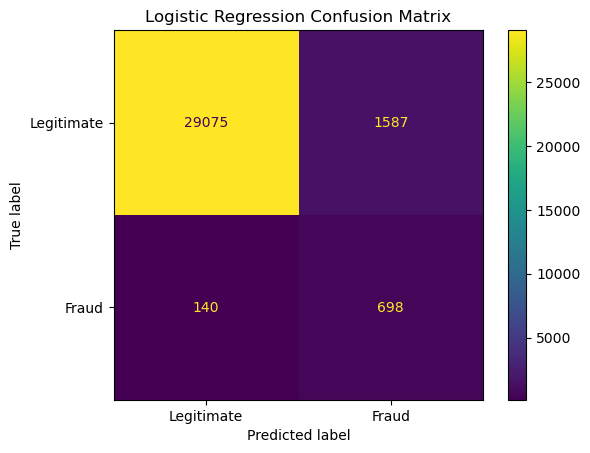

In [20]:
# Logistic Regression confusion matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

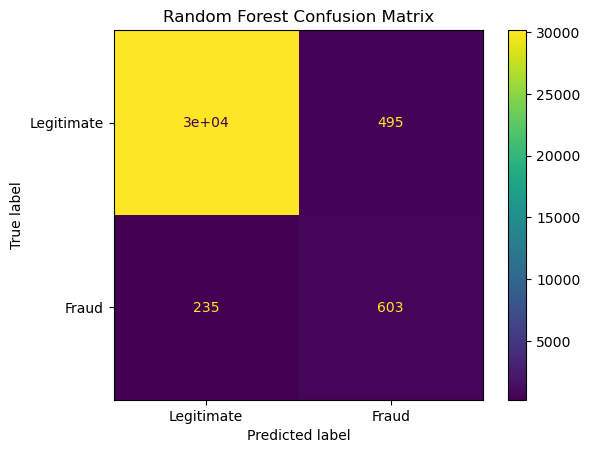

In [21]:
# Random Forest confusion matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

# CLASSIFICATION REPORTS

## Detailed Classification Reports

In [22]:
# CLASSIFICATION REPORTS

print("LOGISTIC REGRESSION")
print("=" * 60)
print(classification_report(
    y_test, y_pred_lr,
    target_names=["Legitimate", "Fraud"],
    digits=4,
    zero_division=0
))

print("\nRANDOM FOREST")
print("=" * 60)
print(classification_report(
    y_test, y_pred_rf,
    target_names=["Legitimate", "Fraud"],
    digits=4,
    zero_division=0
))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

  Legitimate     0.9952    0.9482    0.9712     30662
       Fraud     0.3055    0.8329    0.4470       838

    accuracy                         0.9452     31500
   macro avg     0.6503    0.8906    0.7091     31500
weighted avg     0.9769    0.9452    0.9572     31500


RANDOM FOREST
              precision    recall  f1-score   support

  Legitimate     0.9923    0.9839    0.9880     30662
       Fraud     0.5492    0.7196    0.6229       838

    accuracy                         0.9768     31500
   macro avg     0.7707    0.8517    0.8055     31500
weighted avg     0.9805    0.9768    0.9783     31500



# RANDOM FOREST FEATURE IMPORTANCE

## Identify Important Predictive Features

Feature importance helps explain which available variables the Random Forest used most strongly. These are predictive signals, not proof that a feature causes fraud.

In [23]:
# RANDOM FOREST FEATURE IMPORTANCE

feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("Top 20 Random Forest Features:")
display(feature_importance.head(20))

Top 20 Random Forest Features:


,Feature,Importance
55,remainder__transaction_velocity_1h,0.181226
69,remainder__high_velocity_flag,0.177967
62,remainder__log_amount_to_avg_ratio,0.107952
53,remainder__amount_to_avg_ratio,0.099793
68,remainder__high_amount_ratio_flag,0.066527
4,categorical__kyc_tier_tier3_enhanced,0.031522
20,categorical__merchant_category_payroll transfer,0.030831
30,categorical__channel_mobile app,0.024991
3,categorical__kyc_tier_tier2_verified,0.022380
32,categorical__channel_web dashboard,0.018233


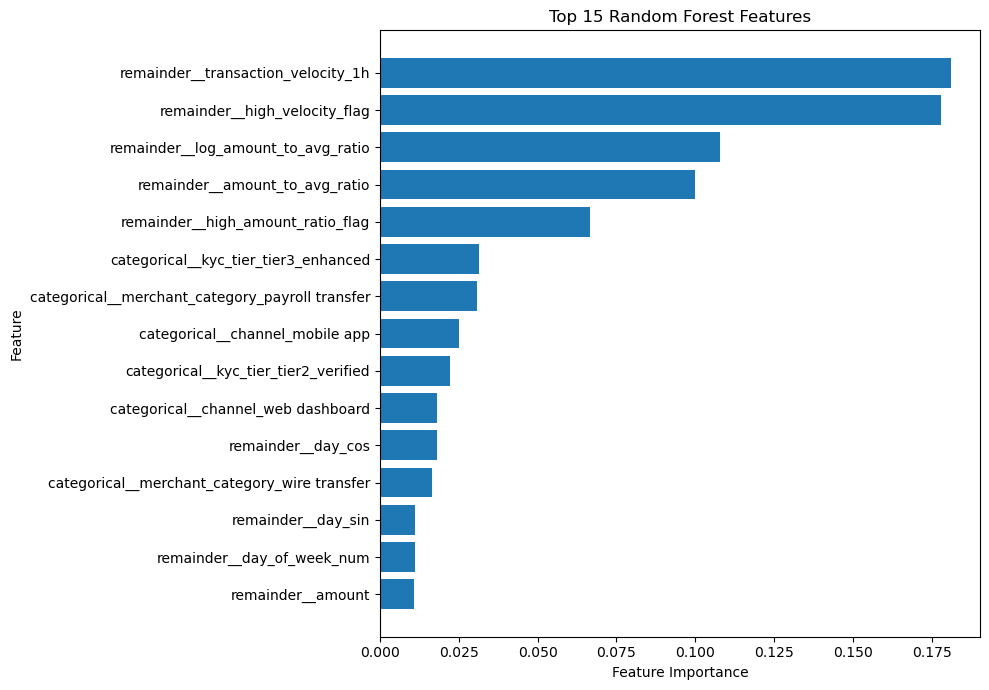

In [24]:
#  PLOT TOP 15 FEATURES

top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Features")
plt.tight_layout()
plt.show()

# FRAUD RISK SCORING

## Generate Fraud Risk Scores

The Random Forest fraud probability is converted to a percentage. These scores can support analyst prioritisation in the prototype.

In [25]:
# CREATE FRAUD RISK SCORES
risk_scores = y_proba_rf * 100

risk_results = X_test.copy()

risk_results["actual_fraud"] = y_test.values
risk_results["fraud_probability"] = y_proba_rf
risk_results["risk_score"] = risk_scores
risk_results["predicted_fraud"] = y_pred_rf

print("Sample fraud risk scores:")
display(
    risk_results[
        ["risk_score", "fraud_probability",
         "predicted_fraud", "actual_fraud"]
    ].head(20)
)

Sample fraud risk scores:


,risk_score,fraud_probability,predicted_fraud,actual_fraud
34855,2.150942,0.021509,0,0
113093,3.580619,0.035806,0,0
10602,4.881057,0.048811,0,0
75718,3.802793,0.038028,0,0
8346,4.881122,0.048811,0,0
26277,6.793043,0.067930,0,0
111816,2.601416,0.026014,0,0
69610,39.401443,0.394014,0,0
48007,4.757654,0.047577,0,0
18674,90.672218,0.906722,1,1


## Prototype Risk Categories

For demonstration only:

- Below 30% = Low Risk
- 30% to below 70% = Medium Risk
- 70% and above = High Risk

These thresholds should be validated before operational use.

In [26]:
# CREATE PROTOTYPE RISK CATEGORIES

risk_results["risk_category"] = pd.cut(
    risk_results["risk_score"],
    bins=[-1, 30, 70, 100],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

print("Risk category distribution:")
print(risk_results["risk_category"].value_counts())

Risk category distribution:
risk_category
Low Risk       29498
Medium Risk     1391
High Risk        611
Name: count, dtype: int64


# FINAL MODEL DEVELOPMENT SUMMARY

The pipeline is now organised as:

1. Load feature-engineered data.
2. Define predictors and target.
3. Identify categorical and numerical features.
4. Stratified 75/25 train-test split.
5. One-hot encode categorical features.
6. Apply SMOTE to training data only.
7. Scale data for Logistic Regression.
8. Train Logistic Regression.
9. Train Random Forest.
10. Generate predictions and fraud probabilities.
11. Evaluate both models.
12. Compare performance.
13. Produce confusion matrices.
14. Analyse Random Forest feature importance.
15. Generate prototype fraud risk scores.

The next analysis can evaluate precision at fixed recall levels of 70%, 80% and 90% to examine different fraud-monitoring operating thresholds.

# SAVE TRAINED MODELS FOR STREAMLIT DEPLOYMENT

In [28]:
# Create a folder for the trained model files
model_folder = "models"
os.makedirs(model_folder, exist_ok=True)

In [29]:
# Save the Random Forest model
joblib.dump(
    rf_model,
    os.path.join(model_folder, "random_forest_model.pkl")
)

['models\\random_forest_model.pkl']

In [30]:
# Save the Logistic Regression model
joblib.dump(
    logistic_model,
    os.path.join(model_folder, "logistic_regression_model.pkl")
)

['models\\logistic_regression_model.pkl']

In [31]:
# Save the One-Hot Encoder / preprocessing object
joblib.dump(
    preprocessor,
    os.path.join(model_folder, "preprocessor.pkl")
)

['models\\preprocessor.pkl']

In [32]:
# Save the StandardScaler used by Logistic Regression
joblib.dump(
    scaler,
    os.path.join(model_folder, "scaler.pkl")
)

['models\\scaler.pkl']

In [33]:
# Save the list of features used by the models
joblib.dump(
    X.columns.tolist(),
    os.path.join(model_folder, "model_features.pkl")
)

['models\\model_features.pkl']

In [34]:
print("All model files saved successfully.")
print("\nSaved files:")

for file in os.listdir(model_folder):
    print("-", file)

All model files saved successfully.

Saved files:
- Finlora_Model_Dev.ipynb
- logistic_regression_model.pkl
- model_features.pkl
- preprocessor.pkl
- random_forest_model.pkl
- scaler.pkl
